# BrushEdit: Qualitative Baseline Evaluation

This notebook runs [BrushEdit](https://github.com/TencentARC/BrushEdit) (Li et al., arXiv:2412.10316) as a baseline comparison against the proposed regional cross-attention method. It uses the exact same three content photographs, C1 masks, and text prompts as the rest of the benchmark.

---

### Key Operational Details

* **Input Data:** Loads assets directly from Part 1's exported `manifest.json` on Google Drive. This prevents transcription errors and guarantees identical inputs.
* **Environment Isolation:** BrushEdit requires a custom fork of `diffusers` that conflicts with `diffusers==0.31.0`. To prevent dependency issues, it installs into an isolated virtual environment (`--system-site-packages` to reuse the CUDA/PyTorch runtime) and executes runs as a subprocess.
* **Checkpoint Caching:** Initial setup downloads approximately 8 GB of weights (BrushNetX and DreamShaper 8). Progress is tracked in `stage_state.json` so subsequent runs skip setup.
* **Export & Scoring:** The notebook produces `BRUSHEDIT_BASELINE_EXPORT.zip` containing generated images and a manifest. Part 2 reads this archive directly, verifies the SHA-256 hashes, and evaluates both BrushEdit and SDXL using the standard metric code.

---

BrushEdit uses the identical content images, two-region masks, and text prompts as the other evaluated methods.

However, it is classified as a **secondary architectural comparator** rather than a primary direct baseline due to three structural differences:

1. **No Image-Based Style Conditioning:** Unlike Method F, Sequential, Global, and Rectangular baselines, BrushEdit does not take reference images (e.g., Van Gogh or Cézanne paintings). It guides stylization entirely through text prompts.
2. **Different Model Weights:** It runs on BrushNetX with a DreamShaper 8 backbone rather than Stable Diffusion 1.5 inpainting with IP-Adapter.
3. **Hard Unmasked Restoration:** BrushEdit uses blended restoration (`GEN_BLENDED = True`), which pastes the unmasked content image back pixel-for-pixel after each edit.

Because of these differences, BrushEdit serves as an external check on how a dedicated instruction-guided editing model handles these regional constraints, rather than an equal-information competitor for exemplar style transfer.

## 1. Packages


In [ ]:
%%capture
!pip install -q huggingface_hub pillow numpy matplotlib requests


## 2. Configuration

In [ ]:
import os, sys, json, gc, io, glob, zipfile, re

# Xet's background writer doesn't play nice with the NFS-mounted home dir this was
# originally run on, so disable it and fall back to plain HTTP downloads.
os.environ['HF_HUB_DISABLE_XET'] = '1'

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.isdir('/content/drive/MyDrive'), (
        "Drive didn't mount -- approve the prompt and re-run this cell")
    _default_baselines_work = '/content/drive/MyDrive/baselines'
else:
    _default_baselines_work = os.path.join(os.getcwd(), 'baselines_work')

BASELINES_WORK = os.environ.get('BASELINES_WORK_DIR', _default_baselines_work)
print("BASELINES_WORK (must match Part 1/Part 2's work_dir):", BASELINES_WORK)

BRUSHEDIT_BRIDGE_DIR = f'{BASELINES_WORK}/brushedit_bridge'
MANIFEST_PATH = f'{BRUSHEDIT_BRIDGE_DIR}/manifest.json'
BRUSHEDIT_RESULTS_PATH = f'{BASELINES_WORK}/brushedit_results.json'  # same path Part 2 expects
BRIDGE_ZIP_NAME = None


def _find_and_extract_bridge_zip():
    candidates = glob.glob('/content/*.zip') + glob.glob(os.path.join(os.getcwd(), '*.zip'))
    for path in sorted(set(candidates), key=os.path.getmtime, reverse=True):
        with zipfile.ZipFile(path) as zf:
            if 'manifest.json' in zf.namelist():
                os.makedirs(BRUSHEDIT_BRIDGE_DIR, exist_ok=True)
                zf.extractall(BRUSHEDIT_BRIDGE_DIR)
                print(f'unzipped {path} into {BRUSHEDIT_BRIDGE_DIR}')
                if len(candidates) > 1:
                    print(f'  NOTE: {len(set(candidates))} zip file(s) were present; used the newest one with a '
                          f'manifest.json. Check this is the bridge from the Part 1 run you intend.')
                global BRIDGE_ZIP_NAME
                BRIDGE_ZIP_NAME = os.path.basename(path)
                return True
    return False


if not os.path.exists(MANIFEST_PATH) and not _find_and_extract_bridge_zip():
    if 'google.colab' in sys.modules:
        print('no manifest found yet -- upload brushedit_bridge_<RUN_ID>.zip')
        from google.colab import files
        files.upload()
        _find_and_extract_bridge_zip()

assert os.path.exists(MANIFEST_PATH), (
    f"{MANIFEST_PATH} not found -- upload the bridge zip from Part 1, or mount "
    f"the Drive folder it was written to")

with open(MANIFEST_PATH) as f:
    MANIFEST = json.load(f)
print(f'{len(MANIFEST)} samples in manifest: {list(MANIFEST)}')
BRIDGE_RUN_ID = os.environ.get('BRIDGE_RUN_ID') or (re.search(r'QUALRUN_\d{8}T\d{6}Z', BRIDGE_ZIP_NAME or '') or [None])[0]
print('bridge run id:', BRIDGE_RUN_ID or 'UNKNOWN -- set BRIDGE_RUN_ID (the RUN_ID Part 1 printed) so the export can be cross-checked')

ROOT = f'{BASELINES_WORK}/brushedit'
WORK_DIR = f'{ROOT}/work'
OUT_DIR = f'{ROOT}/outputs'
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

HF_TOKEN = os.environ.get('HF_TOKEN', '')
GEN_SEED = 42
GEN_STEPS = 30
GEN_GUIDANCE = 7.5
GEN_STRENGTH = 1.0
GEN_NEGATIVE = 'ugly, blurry, distorted, watermark, hard seam'
GEN_BLENDED = True
MAX_SIDE = 512

print(f'BrushEdit root: {ROOT}')
print(f'outputs: {OUT_DIR}')

Mounted at /content/drive
BASELINES_WORK (must match Part 1/Part 2's work_dir): /content/drive/MyDrive/baselines
no manifest found yet -- upload brushedit_bridge_<RUN_ID>.zip


Saving brushedit_bridge_QUALRUN_20260919T082948Z.zip to brushedit_bridge_QUALRUN_20260919T082948Z.zip
unzipped /content/brushedit_bridge_QUALRUN_20260919T082948Z.zip into /content/drive/MyDrive/baselines/brushedit_bridge
  NOTE: 1 zip file(s) were present; used the newest one with a manifest.json. Check this is the bridge from the Part 1 run you intend.
3 samples in manifest: ['QUAL_01', 'QUAL_02', 'QUAL_03']
bridge run id: QUALRUN_20260919T082948Z
BrushEdit root: /content/drive/MyDrive/baselines/brushedit
outputs: /content/drive/MyDrive/baselines/brushedit/outputs


## 2a. Method metadata

In [ ]:
METHOD_METADATA = {
    'BrushEdit': {
        'method_group': 'secondary',
        'backbone': 'TencentARC/BrushEdit (BrushNetX + DreamShaper 8)',
        'backbone_revision': None,
        'ip_adapter_checkpoint': None,
        'ip_adapter_scale': None,
        'num_steps_per_pass': GEN_STEPS,
        'num_passes': 2,
        'total_diffusion_steps': GEN_STEPS * 2,
        'guidance_scale': GEN_GUIDANCE,
        'strength': GEN_STRENGTH,
        'spatial_routing': 'sequential, one region at a time, text-instruction only',
        'postprocessing': None,
        'compositing': 'unmasked region pasted back from the input, pixel-exact',
        'notes': ("no style images given to it, different backbone to the IP-Adapter "
                  "methods; secondary comparator, not an equal-information baseline"),
    },
    'SDXL text-only': {
        'method_group': 'secondary',
        'backbone': 'diffusers/stable-diffusion-xl-1.0-inpainting-0.1', 'backbone_revision': None,
        'ip_adapter_checkpoint': None, 'ip_adapter_scale': None,
        'num_steps_per_pass': GEN_STEPS, 'num_passes': 1, 'total_diffusion_steps': GEN_STEPS,
        'guidance_scale': GEN_GUIDANCE, 'strength': None,
        'spatial_routing': 'none (text-only, one joint prompt over the union mask)',
        'postprocessing': 'SDXL runs at 1024x1024 internally; output resized to the 512x512 content size (LANCZOS)',
        'compositing': 'diffusion-native (single pass)',
        'notes': ('text-only conditioning comparator, receives no style reference image and no per-region '
                  'routing; strength is the pipeline default (not set explicitly)'),
    },
}
print('method metadata defined for:', list(METHOD_METADATA))

method metadata defined for: ['BrushEdit', 'SDXL text-only']


## 3. Build EDITS from the manifest

In [ ]:
import numpy as np
def _resolve(stored_path):
    return os.path.join(BRUSHEDIT_BRIDGE_DIR, os.path.basename(stored_path))


import hashlib as _hl


def _file_sha(p):
    h = _hl.sha256()
    with open(p, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()
_bad, _n = [], 0
for sid, m in MANIFEST.items():
    if m.get('mask_npy_matches_png') is False:
        _bad.append(f'{sid}: bridge reports its .npy masks differ from the PNG masks Part 1 hashed')
    for label, path, want in (
            ('content', m['content'], m.get('content_sha256')),
            ('mask1 .npy', m['mask_region1'], m['mask1_npy_sha256'] if 'mask1_npy_sha256' in m else m.get('mask1_sha256')),
            ('mask2 .npy', m['mask_region2'], m['mask2_npy_sha256'] if 'mask2_npy_sha256' in m else m.get('mask2_sha256'))):
        if want is None:
            _bad.append(f'{sid}: no recorded hash for {label}'); continue
        _n += 1
        got = _file_sha(_resolve(path))
        if got != want:
            _bad.append(f'{sid}: {label} sha256 mismatch (file {got[:12]} vs manifest {want[:12]})')
assert not _bad, 'BRIDGE INPUT VERIFICATION FAILED:\n  ' + '\n  '.join(_bad)
print(f'bridge input verification: {_n} files re-hashed, all match the manifest')


EDITS = []
for sid, m in MANIFEST.items():
    mask1 = np.load(_resolve(m['mask_region1']))
    mask2 = np.load(_resolve(m['mask_region2']))
    EDITS.append({
        'id': sid,
        'image': _resolve(m['content']),
        'steps': [
            {'mask': mask1, 'prompt': m['prompt1'], 'negative': m['negative'],
             'seed': m['seed'], 'steps': m['steps'], 'guidance': m['guidance']},
            {'mask': mask2, 'prompt': m['prompt2'], 'negative': m['negative'],
             'seed': m['seed'], 'steps': m['steps'], 'guidance': m['guidance']},
        ],
    })

print(f'{len(EDITS)} edit(s) built from manifest:')
for e in EDITS:
    print(f"{e['id']}: {len(e['steps'])} step(s), prompts:")
    for st in e['steps']:
        print(f"{st['prompt'][:70]}...")

bridge input verification: 9 files re-hashed, all match the manifest
3 edit(s) built from manifest:
QUAL_01: 2 step(s), prompts:
sky, thick impasto brushwork, swirling expressive daylight strokes, sa...
mountain landscape, structured geometric brushwork, muted earthy green...
QUAL_02: 2 step(s), prompts:
sky, thick impasto brushwork, swirling expressive daylight strokes, sa...
mountain landscape, structured geometric brushwork, muted earthy green...
QUAL_03: 2 step(s), prompts:
sky, thick impasto brushwork, swirling expressive daylight strokes, sa...
mountain landscape, structured geometric brushwork, muted earthy green...


## 3b. Resolve masks

QUAL_01: 512x512, 2 step(s)
QUAL_02: 512x512, 2 step(s)
QUAL_03: 512x512, 2 step(s)


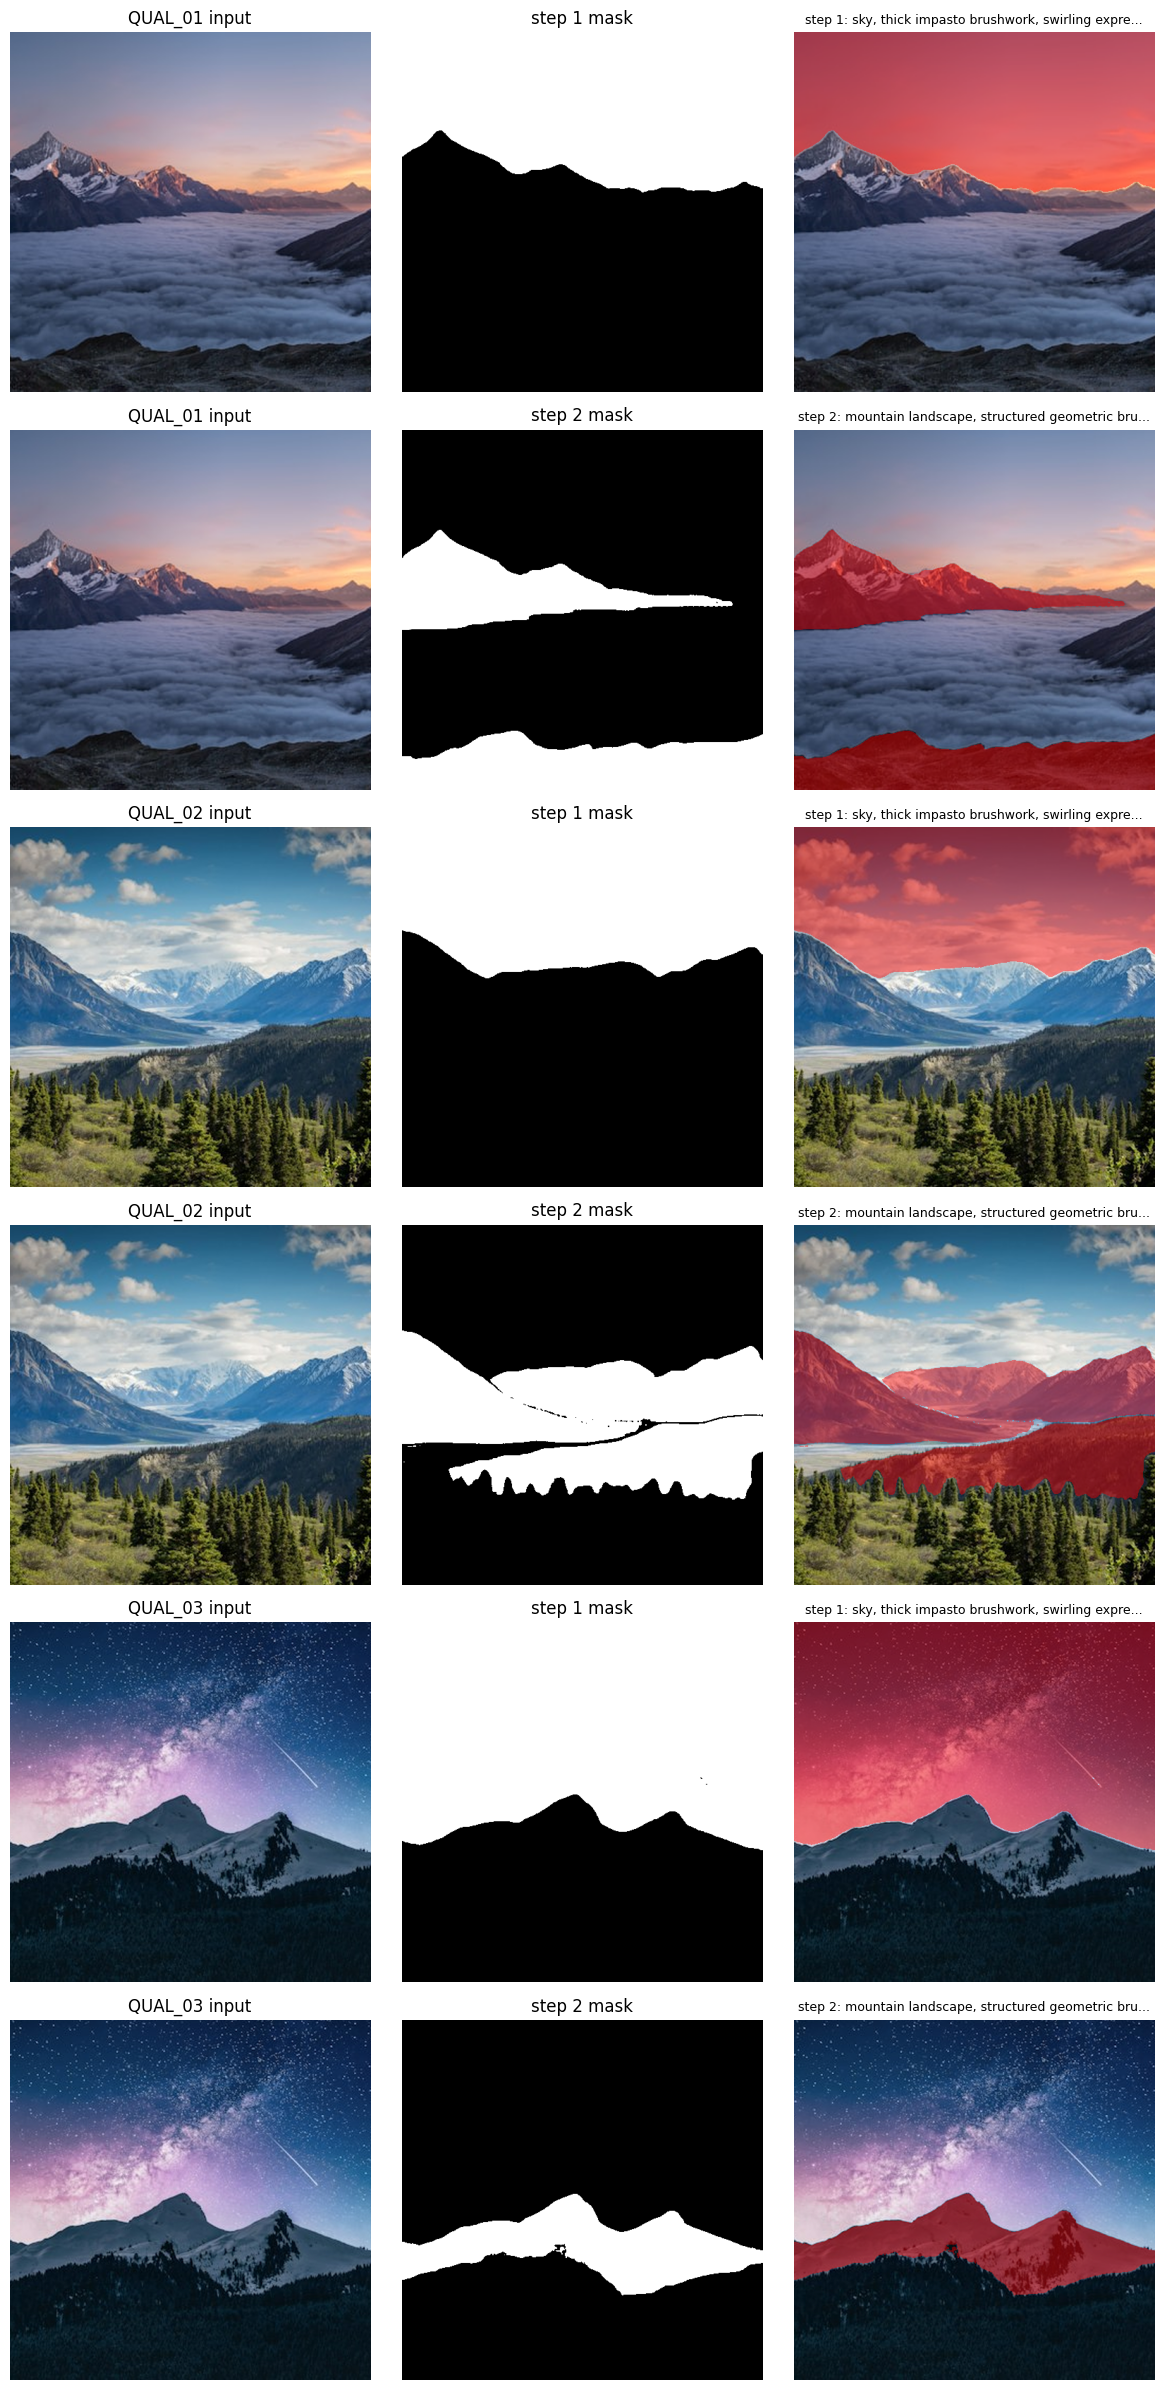

In [ ]:
import io
import urllib.request
import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt


def load_image(src):
    # Handle direct PIL objects, web URLs, or local file paths
    if isinstance(src, Image.Image):
        return src.convert('RGB')
    if isinstance(src, str) and src.startswith(('http://', 'https://')):
        req = urllib.request.Request(src, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=60) as r:
            return Image.open(io.BytesIO(r.read())).convert('RGB')
    return Image.open(src).convert('RGB')


def fit_size(img, max_side=MAX_SIDE):
    # Scale longest dimension to max_side while keeping dimensions divisible by 8 for UNet compatibility
    w, h = img.size
    scale = max_side / max(w, h)
    nw, nh = max(8, int(round(w * scale / 8)) * 8), max(8, int(round(h * scale / 8)) * 8)
    return img.resize((nw, nh), Image.LANCZOS)


def _coord(v, extent):
    # Support normalized ratios (<= 1.0) or absolute pixel values (> 1.0)
    v = float(v)
    return int(round(v * extent)) if v <= 1.0 else int(round(v))


def build_mask(spec, size, grow_px=0):
    # Convert arrays, geometric shorthands, or mask images into a clean binary uint8 mask
    W, H = size

    if isinstance(spec, np.ndarray):
        m = spec.astype(np.uint8)
        if m.max() <= 1:
            m = m * 255
        m = np.array(Image.fromarray(m).resize((W, H), Image.NEAREST))
    elif isinstance(spec, Image.Image):
        m = np.array(spec.convert('L').resize((W, H), Image.NEAREST))
    elif isinstance(spec, str) and ':' in spec and spec.split(':', 1)[0] in (
            'top', 'bottom', 'left', 'right', 'box'):
        # Parse directional split or bounding box notation
        kind, arg = spec.split(':', 1)
        m = np.zeros((H, W), np.uint8)
        if kind == 'top':
            m[:_coord(arg, H), :] = 255
        elif kind == 'bottom':
            m[H - _coord(arg, H):, :] = 255
        elif kind == 'left':
            m[:, :_coord(arg, W)] = 255
        elif kind == 'right':
            m[:, W - _coord(arg, W):] = 255
        else:
            x0, y0, x1, y1 = [p.strip() for p in arg.split(',')]
            m[_coord(y0, H):_coord(y1, H), _coord(x0, W):_coord(x1, W)] = 255
    elif isinstance(spec, str) and spec.strip().lower() == 'full':
        m = np.full((H, W), 255, np.uint8)
    elif isinstance(spec, str):
        m = np.array(load_image(spec).convert('L').resize((W, H), Image.NEAREST))
    else:
        raise ValueError(f'unrecognised mask spec: {spec!r}')

    # Binarize to 0 or 255
    m = np.where(m > 127, 255, 0).astype(np.uint8)

    # Optional morphological dilation to expand the edit region boundary
    if grow_px:
        k = int(grow_px) * 2 + 1
        m = np.array(Image.fromarray(m).filter(ImageFilter.MaxFilter(k if k % 2 else k + 1)))

    # Guard against accidental empty regions
    if m.max() == 0:
        raise ValueError(f'mask spec {spec!r} produced an empty mask -- nothing would be edited')
    return m


def overlay(img, mask, colour=(255, 0, 0), alpha=0.45):
    # Blend a colored overlay on top of masked areas for visual sanity checks
    base = np.array(img).astype(np.float32)
    tint = np.zeros_like(base)
    tint[:] = colour
    sel = (mask > 127)[..., None]
    return Image.fromarray(np.where(sel, base * (1 - alpha) + tint * alpha, base).astype(np.uint8))


# Load each sample, resize, and precompute its binary masks
PREPPED = []
for e in EDITS:
    img = fit_size(load_image(e['image']))
    steps = []
    for i, st in enumerate(e['steps']):
        steps.append({**st, 'mask_arr': build_mask(st['mask'], img.size, st.get('grow_px', 0))})
    PREPPED.append({'id': e['id'], 'image': img, 'steps': steps})
    print(f"{e['id']}: {img.size[0]}x{img.size[1]}, {len(steps)} step(s)")

# Plot input images alongside their mask arrays and red tint overlays
n_rows = sum(len(p['steps']) for p in PREPPED)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 4 * n_rows), squeeze=False)
r = 0
for p in PREPPED:
    for i, st in enumerate(p['steps']):
        axes[r][0].imshow(p['image'])
        axes[r][0].set_title(f"{p['id']} input")
        axes[r][1].imshow(st['mask_arr'], cmap='gray')
        axes[r][1].set_title(f"step {i+1} mask")
        axes[r][2].imshow(overlay(p['image'], st['mask_arr']))
        axes[r][2].set_title(f"step {i+1}: {st['prompt'][:44]}...", fontsize=9)
        for c in range(3):
            axes[r][c].axis('off')
        r += 1
plt.tight_layout()
plt.show()

## 4. Install BrushEdit and run

This implementation incorporates several structural improvements over the default setup. On the initial execution, it provisions an isolated virtual environment, clones the BrushEdit repository, and installs its custom `diffusers` fork alongside only the necessary runtime dependencies (bypassing the full Gradio demo requirements, which contain build-isolated source packages prone to pip compilation errors). It then downloads the BrushNetX and DreamShaper 8 weights (~8 GB).

Setup progress is checkpointed in `stage_state.json` on Google Drive, allowing subsequent sessions to skip already-completed steps. The virtual environment itself resides on the local runtime disk rather than Google Drive to avoid symlink restrictions on Drive's FUSE mount, ensuring fast and reliable environment rebuilds across notebook sessions.

In [ ]:
import os
import sys
import gc
import json
import subprocess as _subprocess
import torch

# Directory configuration
BRUSHEDIT_ROOT = f'{WORK_DIR}/brushedit'
BRUSHEDIT_VENV_DIR = os.path.expanduser('~/brushedit_venv')
BRUSHEDIT_REPO_DIR = f'{BRUSHEDIT_ROOT}/BrushEdit'
BRUSHNETX_DIR = f'{BRUSHEDIT_ROOT}/ckpt/brushnetX'
BASE_MODEL_DIR = f'{BRUSHEDIT_ROOT}/ckpt/base_model/dreamshaper_8'
STATE_PATH = f'{BRUSHEDIT_ROOT}/stage_state.json'
os.makedirs(BRUSHEDIT_ROOT, exist_ok=True)

# Hardware check
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    print('WARNING: no GPU visible, BrushEdit will be extremely slow on CPU.')

# Resume tracker to avoid redundant downloads or builds
_be_state = json.load(open(STATE_PATH)) if os.path.exists(STATE_PATH) else {}


def _be_report(stage, status, detail=''):
    _be_state[stage] = {'status': status, 'detail': detail}
    with open(STATE_PATH, 'w') as f:
        json.dump(_be_state, f, indent=2)
    print(f'[{status.upper()}] {stage}' + (f': {detail}' if detail else ''))


def _be_passed(stage):
    return _be_state.get(stage, {}).get('status') == 'pass'


def _venv_python():
    return f'{BRUSHEDIT_VENV_DIR}/bin/python'


def _pip(*args, timeout=1200, cwd=None, what='pip install'):
    # Run pip inside the isolated virtualenv
    r = _subprocess.run([_venv_python(), '-m', 'pip', 'install', '-q', *args],
                        cwd=cwd, capture_output=True, text=True, timeout=timeout)
    if r.returncode != 0:
        print(f'--- {what}: pip stderr (tail) ' + '-' * 30)
        print(r.stderr[-5000:])
        if r.stdout.strip():
            print(f'--- {what}: pip stdout (tail) ' + '-' * 30)
            print(r.stdout[-2000:])
        raise RuntimeError(f'{what} failed, check pip logs above')


try:
    # 1. Virtual environment setup on local storage
    if _be_passed('venv') and os.path.exists(_venv_python()):
        print('venv already set up, skipping')
    else:
        r = _subprocess.run(
            [sys.executable, '-m', 'venv', '--system-site-packages', '--without-pip', BRUSHEDIT_VENV_DIR],
            capture_output=True, text=True, timeout=180,
        )
        if r.returncode != 0:
            raise RuntimeError(f'venv creation failed: {r.stderr[-800:]}')

        verify_pip = _subprocess.run([_venv_python(), '-m', 'pip', '--version'],
                                     capture_output=True, text=True, timeout=60)
        if verify_pip.returncode != 0:
            raise RuntimeError(f'venv has no usable pip: {verify_pip.stderr[-800:]}')

        _be_state.pop('install_v3', None)
        _be_report('venv', 'pass', BRUSHEDIT_VENV_DIR)

    # 2. Clone repository and install dependencies
    if _be_passed('install_v3'):
        print('BrushEdit repo + fork already installed, skipping')
    else:
        if not os.path.exists(BRUSHEDIT_REPO_DIR):
            r = _subprocess.run(
                ['git', 'clone', '-q', 'https://github.com/TencentARC/BrushEdit.git', BRUSHEDIT_REPO_DIR],
                capture_output=True, text=True, timeout=600,
            )
            if r.returncode != 0:
                raise RuntimeError(f'git clone failed: {r.stderr[-800:]}')

        # Force install the local diffusers fork without pulling heavy torch dependencies already in base
        _pip('-e', '.', '--force-reinstall', '--no-deps',
             cwd=BRUSHEDIT_REPO_DIR, what='pip install -e . (diffusers fork)')

        # Install minimal runtime dependencies needed by BrushEdit pipeline
        _pip('pillow', 'transformers==4.46.3', 'accelerate==0.26.0', 'huggingface_hub==0.23.2',
             'safetensors', timeout=900, what='BrushEdit runtime deps')

        # Keep numpy >= 2 compatible with transformers CLIP image processor and modern headless opencv
        _pip('--force-reinstall', 'numpy>=2,<3', 'opencv-python-headless', timeout=600,
             what='numpy/opencv pin')

        # Verify that the custom pipeline module loads correctly
        _verify_src = (
            'import huggingface_hub\n'
            'if not hasattr(huggingface_hub, "cached_download"):\n'
            '    huggingface_hub.cached_download = lambda *a, **k: None\n'
            'from diffusers import StableDiffusionBrushNetPipeline\n'
            'from app.src.brushedit_all_in_one_pipeline import BrushEdit_Pipeline\n'
            'print("OK")\n'
        )
        _verify_env = dict(os.environ, PYTHONPATH=f'{BRUSHEDIT_REPO_DIR}/src{os.pathsep}{BRUSHEDIT_REPO_DIR}')
        verify = _subprocess.run([_venv_python(), '-c', _verify_src], cwd=BRUSHEDIT_REPO_DIR,
                                 env=_verify_env, capture_output=True, text=True, timeout=180)
        if verify.returncode != 0 or 'OK' not in verify.stdout:
            raise RuntimeError(f'BrushEdit pipeline verification failed: {verify.stderr[-800:]}')

        _be_report('install_v3', 'pass', BRUSHEDIT_REPO_DIR)

    # Re-apply numpy and opencv pin if fast-skipping
    if _be_passed('install_v3'):
        _pip('--force-reinstall', 'numpy>=2,<3', 'opencv-python-headless', timeout=600,
             what='numpy/opencv pin')

    # 3. Model weights download (BrushNetX and DreamShaper 8)
    if _be_passed('checkpoints'):
        print('checkpoints already downloaded, skipping')
    else:
        from huggingface_hub import snapshot_download
        os.makedirs(os.path.dirname(BRUSHNETX_DIR), exist_ok=True)
        snapshot_download(
            repo_id='TencentARC/BrushEdit',
            allow_patterns=['brushnetX/*', 'base_model/dreamshaper_8/*'],
            local_dir=f'{BRUSHEDIT_ROOT}/ckpt',
            token=HF_TOKEN or None,
        )
        assert os.path.exists(f'{BRUSHNETX_DIR}/config.json'), 'brushnetX/config.json missing'
        assert os.path.exists(f'{BASE_MODEL_DIR}/model_index.json'), 'dreamshaper_8/model_index.json missing'
        _be_report('checkpoints', 'pass', f'{BRUSHNETX_DIR}, {BASE_MODEL_DIR}')

    # 4. Generate driver script to execute inference inside the isolated venv
    driver_path = f'{BRUSHEDIT_ROOT}/brushedit_driver.py'
    driver_src = r'''
import sys, json, os
import numpy as np
import torch
from PIL import Image

spec_path = sys.argv[1]
with open(spec_path) as f:
    spec = json.load(f)

BRUSHEDIT_DIR = spec["brushedit_dir"]
BRUSHNETX_DIR = spec["brushnetx_dir"]
BASE_MODEL_DIR = spec["base_model_dir"]
DEVICE = spec["device"]
ITEMS = spec["items"]

sys.path.insert(0, os.path.join(BRUSHEDIT_DIR, "src"))
sys.path.insert(0, BRUSHEDIT_DIR)

import huggingface_hub
if not hasattr(huggingface_hub, "cached_download"):
    def cached_download(*args, **kwargs):
        raise NotImplementedError("cached_download is unused by this standalone BrushEdit path")
    huggingface_hub.cached_download = cached_download

# Disable PEFT/LoRA modules to prevent version mismatch crashes with pinned accelerate
def _noop_lora_scale(*args, **kwargs):
    return None

sys.modules["peft"] = None

import diffusers.utils.peft_utils as _dpu
_dpu.scale_lora_layers = _noop_lora_scale
_dpu.unscale_lora_layers = _noop_lora_scale

import diffusers.pipelines.brushnet.pipeline_brushnet as _brushnet_pipeline
_brushnet_pipeline.scale_lora_layers = _noop_lora_scale
_brushnet_pipeline.unscale_lora_layers = _noop_lora_scale

import diffusers.pipelines.pipeline_loading_utils as plu
plu.is_peft_available = lambda: False

from diffusers import StableDiffusionBrushNetPipeline, BrushNetModel, UniPCMultistepScheduler
from app.src.brushedit_all_in_one_pipeline import BrushEdit_Pipeline

print("PEFT/LoRA disabled for standalone BrushEdit", flush=True)

print("loading BrushNetX...", flush=True)
brushnet = BrushNetModel.from_pretrained(BRUSHNETX_DIR, torch_dtype=torch.float16)

print("loading DreamShaper 8 + BrushNetX...", flush=True)
pipe = StableDiffusionBrushNetPipeline.from_pretrained(
    BASE_MODEL_DIR, brushnet=brushnet, torch_dtype=torch.float16, low_cpu_mem_usage=False)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
print("BrushEdit pipeline loaded", flush=True)

for item in ITEMS:
    iid = item["id"]
    src = Image.open(item["image"]).convert("RGB")
    current = np.array(src)

    for i, step in enumerate(item["steps"]):
        print(f"--- {iid}: step {i+1}/{len(item['steps'])} :: {step['prompt'][:60]} ---", flush=True)

        mask = np.array(Image.open(step["mask"]).convert("L"))
        generator = torch.Generator(DEVICE).manual_seed(int(step["seed"]))

        images, _, _, _ = BrushEdit_Pipeline(
            pipe, step["prompt"], mask, current, generator,
            int(step["steps"]), float(step["guidance"]), float(step["strength"]),
            step["negative"], 1, bool(step["blended"]),
        )

        out = images[0].convert("RGB").resize(src.size, Image.LANCZOS)
        out.save(step["step_output"])
        current = np.array(out)

    Image.fromarray(current).save(item["output"])
    print(f"{iid}: saved to {item['output']}", flush=True)

print("ALL_ITEMS_DONE", flush=True)
'''

    with open(driver_path, 'w') as f:
        f.write(driver_src)

    # 5. Prepare input assets, write configuration spec, and execute subprocess
    spec_items = []
    for p in PREPPED:
        iid = p['id']
        item_dir = f'{BRUSHEDIT_ROOT}/inputs/{iid}'
        os.makedirs(item_dir, exist_ok=True)
        img_path = f'{item_dir}/input.png'
        p['image'].save(img_path)
        step_specs = []
        for i, st in enumerate(p['steps']):
            mask_path = f'{item_dir}/mask_{i+1}.png'
            Image.fromarray(st['mask_arr']).save(mask_path)
            step_specs.append({
                'prompt': st['prompt'],
                'mask': mask_path,
                'seed': st.get('seed', GEN_SEED),
                'steps': st.get('steps', GEN_STEPS),
                'guidance': st.get('guidance', GEN_GUIDANCE),
                'strength': st.get('strength', GEN_STRENGTH),
                'negative': st.get('negative', GEN_NEGATIVE),
                'blended': st.get('blended', GEN_BLENDED),
                'step_output': f'{item_dir}/step_{i+1}.png',
            })
        spec_items.append({'id': iid, 'image': img_path, 'steps': step_specs,
                           'output': f'{OUT_DIR}/{iid}_brushedit.png'})

    spec_path = f'{BRUSHEDIT_ROOT}/run_spec.json'
    with open(spec_path, 'w') as f:
        json.dump({'brushedit_dir': BRUSHEDIT_REPO_DIR, 'brushnetx_dir': BRUSHNETX_DIR,
                   'base_model_dir': BASE_MODEL_DIR, 'device': DEVICE,
                   'items': spec_items}, f, indent=2)

    n_passes = sum(len(i['steps']) for i in spec_items)
    print(f'running BrushEdit: {len(spec_items)} image(s), {n_passes} generation pass(es), '
          'the model loads once and is reused')

    _driver_env = dict(os.environ, PYTHONPATH=f'{BRUSHEDIT_REPO_DIR}/src{os.pathsep}{BRUSHEDIT_REPO_DIR}')
    run = _subprocess.run([_venv_python(), driver_path, spec_path], env=_driver_env,
                          capture_output=True, text=True, timeout=7200)
    print(run.stdout[-6000:])
    if run.returncode != 0 or 'ALL_ITEMS_DONE' not in run.stdout:
        print('----- BrushEdit subprocess STDERR -----')
        print(run.stderr[-6000:])
        raise RuntimeError(f'BrushEdit subprocess failed:\n{run.stderr[-6000:]}')

    # 6. Collect final generated outputs
    for p, item in zip(PREPPED, spec_items):
        p['result'] = Image.open(item['output']).convert('RGB')
        p['step_results'] = [Image.open(s['step_output']).convert('RGB')
                             for s in item['steps'] if os.path.exists(s['step_output'])]
        print(f"{p['id']}: done -> {item['output']}")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f'\nBrushEdit failed: {type(e).__name__}: {e}')

# Cleanup memory allocations
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[PASS] venv: /root/brushedit_venv
[PASS] install_v3: /content/drive/MyDrive/baselines/brushedit/work/brushedit/BrushEdit


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

[PASS] checkpoints: /content/drive/MyDrive/baselines/brushedit/work/brushedit/ckpt/brushnetX, /content/drive/MyDrive/baselines/brushedit/work/brushedit/ckpt/base_model/dreamshaper_8
running BrushEdit: 3 image(s), 6 generation pass(es), the model loads once and is reused
PEFT/LoRA disabled for standalone BrushEdit
loading BrushNetX...
loading DreamShaper 8 + BrushNetX...
BrushEdit pipeline loaded
--- QUAL_01: step 1/2 :: sky, thick impasto brushwork, swirling expressive daylight s ---
--- QUAL_01: step 2/2 :: mountain landscape, structured geometric brushwork, muted ea ---
QUAL_01: saved to /content/drive/MyDrive/baselines/brushedit/outputs/QUAL_01_brushedit.png
--- QUAL_02: step 1/2 :: sky, thick impasto brushwork, swirling expressive daylight s ---
--- QUAL_02: step 2/2 :: mountain landscape, structured geometric brushwork, muted ea ---
QUAL_02: saved to /content/drive/MyDrive/baselines/brushedit/outputs/QUAL_02_brushedit.png
--- QUAL_03: step 1/2 :: sky, thick impasto brushwork, swir

## 5. Results

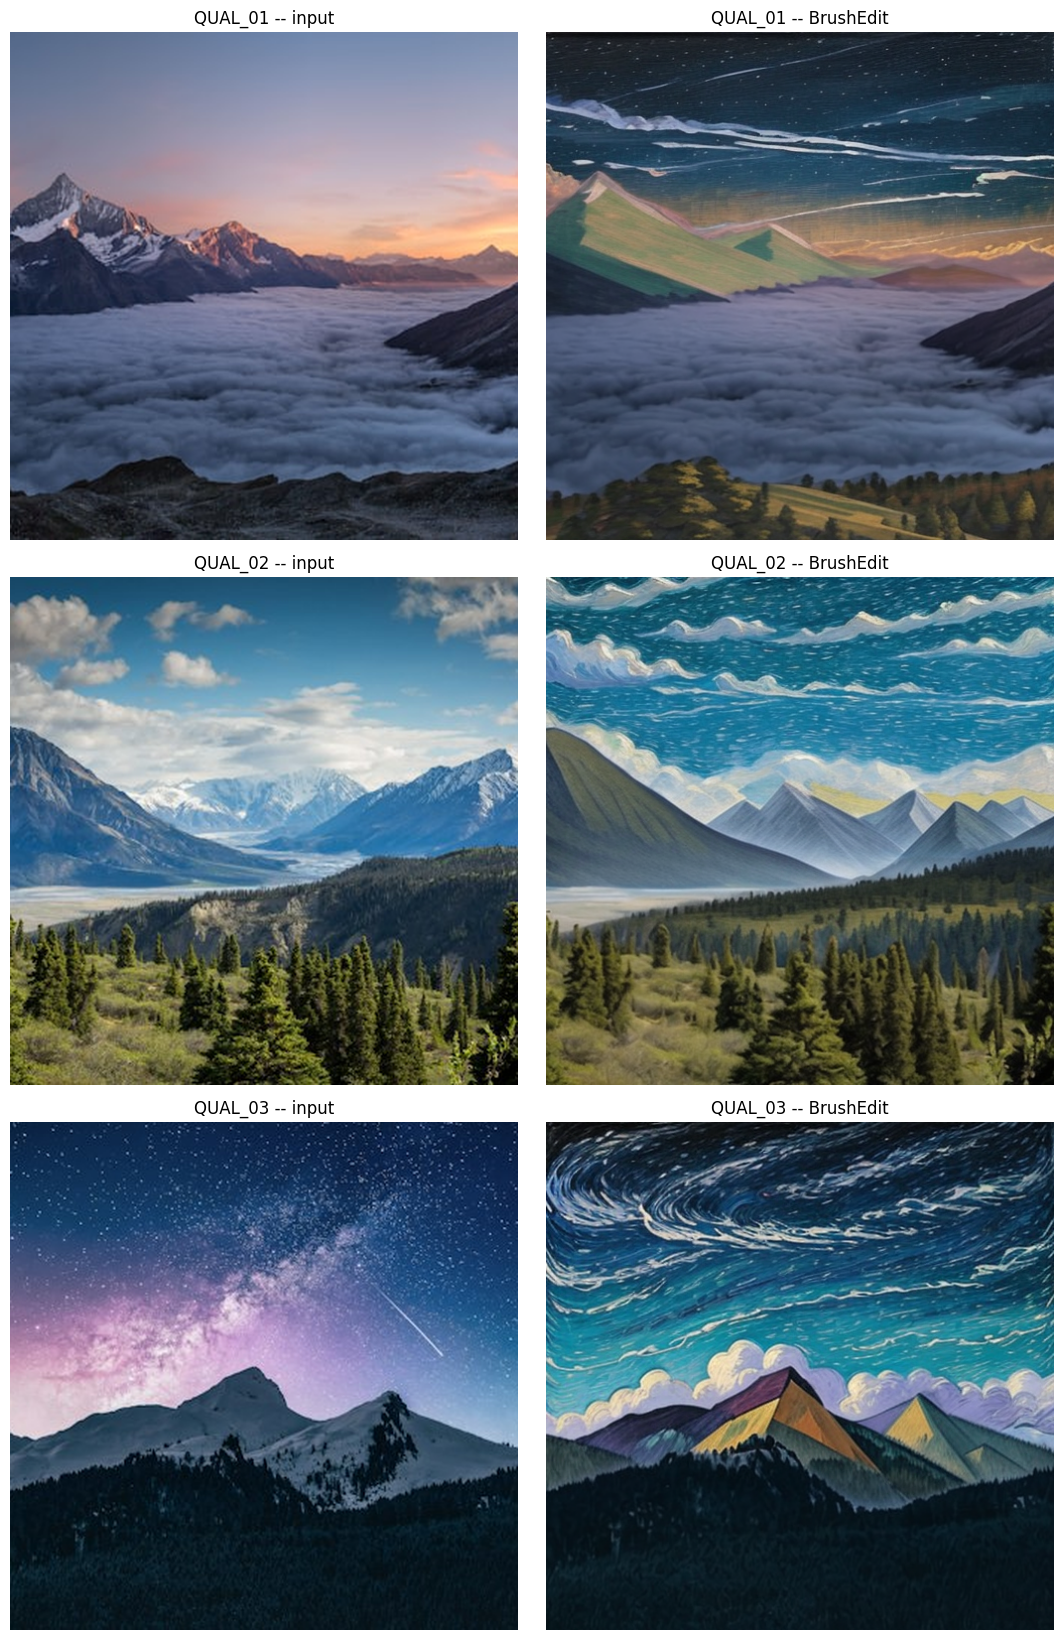

In [ ]:
fig, axes = plt.subplots(len(PREPPED), 2, figsize=(11, 5.5 * len(PREPPED)), squeeze=False)
for r, p in enumerate(PREPPED):
    axes[r][0].imshow(p['image'])
    axes[r][0].set_title(f"{p['id']} input")
    if p.get('result') is not None:
        axes[r][1].imshow(p['result'])
        axes[r][1].set_title(f"{p['id']} -- BrushEdit")
    else:
        axes[r][1].set_title(f"{p['id']} -- no result")
        axes[r][1].text(0.5, 0.5, 'not generated', ha='center', va='center',
                        transform=axes[r][1].transAxes, color='red')
    axes[r][0].axis('off'); axes[r][1].axis('off')
plt.tight_layout()
plt.show()

## 5b. SDXL text-only (conditioning-regime control)

Because Part 2 is constrained by an 8 GB VRAM budget that cannot accommodate SDXL-inpaint, we generate its outputs here within the Colab environment. We maintain standardized generation parameters by using the identical source content images, the spatial union of both C1 region masks, a combined joint prompt (`prompt1, prompt2`), matching negative prompts, random seed, inference steps, and guidance scale.

SDXL receives **no style-reference images** and uses no spatial attention routing. Like BrushEdit, it serves as a conditioning-regime control rather than an equal-information comparator, isolating how an unrouted, text-only state-of-the-art model responds under equivalent mask and prompt constraints. Setting `RUN_SDXL = False` skips generation entirely, omitting SDXL entries from the manifest export so Part 2 records the baseline as skipped.

In [ ]:
RUN_SDXL = True
SDXL_MODEL = 'diffusers/stable-diffusion-xl-1.0-inpainting-0.1'
SDXL_OUT_DIR = f'{ROOT}/outputs_sdxl'
os.makedirs(SDXL_OUT_DIR, exist_ok=True)
SDXL_RESULTS, SDXL_FAILURES, SDXL_LOAD_INFO = {}, [], {}


def _run_sdxl_all():
    import torch
    from diffusers import AutoPipelineForInpainting
    try:
        pipe = AutoPipelineForInpainting.from_pretrained(SDXL_MODEL, torch_dtype=torch.float16,
                                                         variant='fp16', use_safetensors=True)
        SDXL_LOAD_INFO['weights'] = 'fp16 variant'
    except Exception as e:
        print(f'  fp16 variant not loadable ({type(e).__name__}); using default weights cast to fp16')
        pipe = AutoPipelineForInpainting.from_pretrained(SDXL_MODEL, torch_dtype=torch.float16)
        SDXL_LOAD_INFO['weights'] = 'default weights cast to fp16'
    pipe.to('cuda')
    SDXL_LOAD_INFO['placement'] = 'cuda'
    offloaded = False
    for p in PREPPED:
        sid = p['id']
        step1, step2 = p['steps']
        union = np.maximum(step1['mask_arr'], step2['mask_arr'])
        kwargs = dict(prompt=f"{step1['prompt']}, {step2['prompt']}", image=p['image'],
                      mask_image=Image.fromarray(union).convert('L'), negative_prompt=GEN_NEGATIVE,
                      num_inference_steps=GEN_STEPS, guidance_scale=GEN_GUIDANCE)
        for attempt in (1, 2):
            try:
                out = pipe(generator=torch.Generator('cuda').manual_seed(GEN_SEED), **kwargs).images[0]
                break
            except torch.cuda.OutOfMemoryError:
                if attempt == 2 or offloaded:
                    raise
                print(f'  {sid}: CUDA OOM -> retrying with model CPU offload + VAE tiling')
                pipe.to('cpu'); gc.collect(); torch.cuda.empty_cache()
                pipe.enable_model_cpu_offload(); pipe.enable_vae_tiling()
                offloaded = True
                SDXL_LOAD_INFO['placement'] = 'model_cpu_offload + vae_tiling (after OOM on plain cuda)'
        out = out.resize(p['image'].size, Image.LANCZOS)
        path = f'{SDXL_OUT_DIR}/{sid}_sdxl.png'
        out.save(path, 'PNG')
        SDXL_RESULTS[sid] = path
        print(f'  {sid}: SDXL saved -> {path}')
    del pipe
    gc.collect()
    torch.cuda.empty_cache()


if RUN_SDXL:
    print('SDXL text-only: generating (always regenerated, never reused from an earlier bridge)')
    try:
        _run_sdxl_all()
    except Exception as e:
        SDXL_FAILURES.append(f'{type(e).__name__}: {e}')
        print(f'SDXL FAILED -- {type(e).__name__}: {e}  (recorded as failed in the export, not faked)')
    print(f'SDXL: {len(SDXL_RESULTS)}/{len(PREPPED)} generated; load info: {SDXL_LOAD_INFO}')
else:
    print('RUN_SDXL = False ")


SDXL text-only: generating (always regenerated, never reused from an earlier bridge)


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

  QUAL_01: SDXL saved -> /content/drive/MyDrive/baselines/brushedit/outputs_sdxl/QUAL_01_sdxl.png


  0%|          | 0/29 [00:00<?, ?it/s]

  QUAL_02: SDXL saved -> /content/drive/MyDrive/baselines/brushedit/outputs_sdxl/QUAL_02_sdxl.png


  0%|          | 0/29 [00:00<?, ?it/s]

  QUAL_03: SDXL saved -> /content/drive/MyDrive/baselines/brushedit/outputs_sdxl/QUAL_03_sdxl.png
SDXL: 3/3 generated; load info: {'weights': 'fp16 variant', 'placement': 'cuda'}


## 6. Export results, provenance, and a self-contained zip

In [ ]:
import hashlib, shutil, csv


def _sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

_results = {}
for p in PREPPED:
    out_path = f"{OUT_DIR}/{p['id']}_brushedit.png"
    if os.path.exists(out_path):
        _results[p['id']] = out_path
    else:
        print(f"WARNING: {p['id']} has no output at {out_path} -- excluded from export, "
              f"will show as N/A, not silently substituted.")

with open(BRUSHEDIT_RESULTS_PATH, 'w') as f:
    json.dump(_results, f, indent=2)
prov_path = f'{ROOT}/provenance.csv'
fieldnames = ['qual_sample_id', 'method', 'seed', 'content_sha256', 'mask1_sha256',
              'mask2_sha256', 'style1_sha256', 'style2_sha256', 'model',
              'ip_adapter_weight', 'config_hash', 'code_hash', 'output_sha256',
              'C1_METHOD_CONFIG_REFERENCE']
with open(prov_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for sid, m in MANIFEST.items():
        row = {
            'qual_sample_id': sid, 'method': 'BrushEdit', 'seed': m['seed'],
            'content_sha256': m.get('content_sha256'), 'mask1_sha256': m.get('mask1_sha256'),
            'mask2_sha256': m.get('mask2_sha256'), 'style1_sha256': m.get('style1_sha256'),
            'style2_sha256': m.get('style2_sha256'),
            'model': 'TencentARC/BrushEdit (BrushNetX + DreamShaper 8)',
            'ip_adapter_weight': None,   # BrushEdit doesn't use IP-Adapter -- genuinely not applicable, not missing data
            'config_hash': m.get('config_hash'), 'code_hash': None,   # this notebook isn't hash-versioned the way Part 1/2's own code is
            'output_sha256': _sha256_file(_results[sid]) if sid in _results else None,
            'C1_METHOD_CONFIG_REFERENCE': m.get('C1_METHOD_CONFIG_REFERENCE'),
        }
        writer.writerow(row)

print(f'\nwrote {len(_results)}/{len(PREPPED)} BrushEdit result(s)')
print(f'  results json: {BRUSHEDIT_RESULTS_PATH}')
print(f'  provenance csv (same columns as Part 1/2, ready to concatenate): {prov_path}')
zip_path = shutil.make_archive(f'{ROOT}/brushedit_results', 'zip', root_dir=OUT_DIR)
shutil.copy(prov_path, f'{OUT_DIR}/provenance.csv')
shutil.copy(BRUSHEDIT_RESULTS_PATH, f'{OUT_DIR}/brushedit_results.json')
zip_path = shutil.make_archive(f'{ROOT}/brushedit_results', 'zip', root_dir=OUT_DIR)
size_mb = os.path.getsize(zip_path) / 1e6
print(f'\ncreated: {zip_path}  ({size_mb:.1f} MB)self-contained: images + provenance.csv + results json')

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not on Colab")



wrote 3/3 BrushEdit result(s)
  results json: /content/drive/MyDrive/baselines/brushedit_results.json
  provenance csv (same columns as Part 1/2, ready to concatenate): /content/drive/MyDrive/baselines/brushedit/provenance.csv

created: /content/drive/MyDrive/baselines/brushedit/brushedit_results.zip  (1.2 MB)self-contained: images + provenance.csv + results json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7.export for Notebook 4


In [ ]:
import os
import json
import shutil
from datetime import datetime

# Setup export directory paths
EXPORT_DIR = f'{ROOT}/BRUSHEDIT_BASELINE_EXPORT'
EXPORT_OUTPUTS_DIR = f'{EXPORT_DIR}/outputs'
os.makedirs(EXPORT_OUTPUTS_DIR, exist_ok=True)

manifest_rows = []

# Process BrushEdit baseline outputs
meta = METHOD_METADATA['BrushEdit']
for sid, m in MANIFEST.items():
    status = 'ok' if sid in _results else 'failed'
    output_path_rel = None
    if status == 'ok':
        dst_dir = f'{EXPORT_OUTPUTS_DIR}/{sid}'
        os.makedirs(dst_dir, exist_ok=True)
        dst_png = f'{dst_dir}/BrushEdit.png'
        shutil.copy(_results[sid], dst_png)
        output_path_rel = f'outputs/{sid}/BrushEdit.png'

    manifest_rows.append({
        'method_name': 'BrushEdit',
        'method_group': meta['method_group'],
        'sample_id': sid,
        'content_id': sid,
        'style_reference_1': None,
        'style_reference_2': None,
        'style_refs_supplied': False,
        'mask_1': m.get('mask1_sha256'),
        'mask_2': m.get('mask2_sha256'),
        'prompt': f"{m.get('prompt1')} | {m.get('prompt2')}",
        'seed': m.get('seed'),
        'backbone': meta['backbone'],
        'backbone_revision': meta['backbone_revision'],
        'ip_adapter_checkpoint': meta['ip_adapter_checkpoint'],
        'ip_adapter_scale': meta['ip_adapter_scale'],
        'num_steps_per_pass': meta['num_steps_per_pass'],
        'num_passes': meta['num_passes'],
        'total_diffusion_steps': meta['total_diffusion_steps'],
        'guidance_scale': meta['guidance_scale'],
        'strength': meta['strength'],
        'spatial_routing': meta['spatial_routing'],
        'postprocessing': meta['postprocessing'],
        'compositing': meta['compositing'],
        'output_path': output_path_rel,
        'output_sha256': _sha256_file(_results[sid]) if sid in _results else None,
        'status': status,
        'notes': meta['notes'],
    })

_methods_in_export = ['BrushEdit']

# Process SDXL text-only baseline outputs if enabled
if RUN_SDXL:
    _methods_in_export.append('SDXL text-only')
    smeta = METHOD_METADATA['SDXL text-only']
    for sid, m in MANIFEST.items():
        status = 'ok' if sid in SDXL_RESULTS else 'failed'
        output_path_rel = None
        if status == 'ok':
            dst_dir = f'{EXPORT_OUTPUTS_DIR}/{sid}'
            os.makedirs(dst_dir, exist_ok=True)
            shutil.copy(SDXL_RESULTS[sid], f'{dst_dir}/SDXL_text_only.png')
            output_path_rel = f'outputs/{sid}/SDXL_text_only.png'

        manifest_rows.append({
            'method_name': 'SDXL text-only',
            'method_group': smeta['method_group'],
            'sample_id': sid,
            'content_id': sid,
            'style_reference_1': None,
            'style_reference_2': None,
            'style_refs_supplied': False,
            'mask_1': m.get('mask1_sha256'),
            'mask_2': m.get('mask2_sha256'),
            'prompt': f"{m.get('prompt1')} | {m.get('prompt2')}",
            'seed': m.get('seed'),
            'backbone': smeta['backbone'],
            'backbone_revision': smeta['backbone_revision'],
            'ip_adapter_checkpoint': smeta['ip_adapter_checkpoint'],
            'ip_adapter_scale': smeta['ip_adapter_scale'],
            'num_steps_per_pass': smeta['num_steps_per_pass'],
            'num_passes': smeta['num_passes'],
            'total_diffusion_steps': smeta['total_diffusion_steps'],
            'guidance_scale': smeta['guidance_scale'],
            'strength': smeta['strength'],
            'spatial_routing': smeta['spatial_routing'],
            'postprocessing': smeta['postprocessing'],
            'compositing': smeta['compositing'],
            'output_path': output_path_rel,
            'output_sha256': _sha256_file(SDXL_RESULTS[sid]) if status == 'ok' else None,
            'status': status,
            'notes': smeta['notes'],
        })

# Write export metadata files
with open(f'{EXPORT_DIR}/manifest.json', 'w') as f:
    json.dump(manifest_rows, f, indent=2)

with open(f'{EXPORT_DIR}/configs.json', 'w') as f:
    json.dump({
        'gen_seed': GEN_SEED,
        'gen_steps': GEN_STEPS,
        'gen_guidance': GEN_GUIDANCE,
        'gen_strength': GEN_STRENGTH,
        'gen_negative': GEN_NEGATIVE,
        'gen_blended': GEN_BLENDED,
        'max_side': MAX_SIDE
    }, f, indent=2)

package = {
    'package_metadata': {
        'baseline_export_version': '1.0',
        'source_notebook': 'BrushEdit_baseline',
        'generated_at': datetime.now().isoformat(),
    },
    'methods': _methods_in_export,
    'samples': list(MANIFEST),
    'outputs': manifest_rows,
}

with open(f'{EXPORT_DIR}/export_package.json', 'w') as f:
    json.dump(package, f, indent=2)

# Create zip archive for export
zip_path = shutil.make_archive(f'{ROOT}/BRUSHEDIT_BASELINE_EXPORT', 'zip', root_dir=EXPORT_DIR)
print(f'BRUSHEDIT_BASELINE_EXPORT.zip written to {zip_path}')
print(f'Rows: {len(manifest_rows)} (OK: {sum(r["status"]=="ok" for r in manifest_rows)}, '
      f'Failed: {sum(r["status"]=="failed" for r in manifest_rows)})')

BRUSHEDIT_BASELINE_EXPORT.zip written to /content/drive/MyDrive/baselines/brushedit/BRUSHEDIT_BASELINE_EXPORT.zip
  rows: 6  (status ok: 6, failed: 0)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>